## 1/4 ge calibration - DPR1-L-120-44

ge_freq = 8.03+0.005106 GHz

ge_pi_amp = 0.900


T1 = 30.55e-06

T2 = 11.32e-06

T2_star = 6.29e-06

In [2]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [3]:
import sklearn
from sklearn.decomposition import PCA

In [4]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [5]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [6]:
header = "D:/K_Sunada/result/CDY153/"

In [7]:
amp = "/2024-01-04/2024-01-04T134546_2051969b-21_ge_pi_amp"
dd_amp = datadict_from_hdf5(header + amp +"/data")

In [8]:
Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['amplitude']['values']

In [9]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2, pca

In [10]:
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)
PCA_amp = PCA_transform(I_amp, Q_amp)


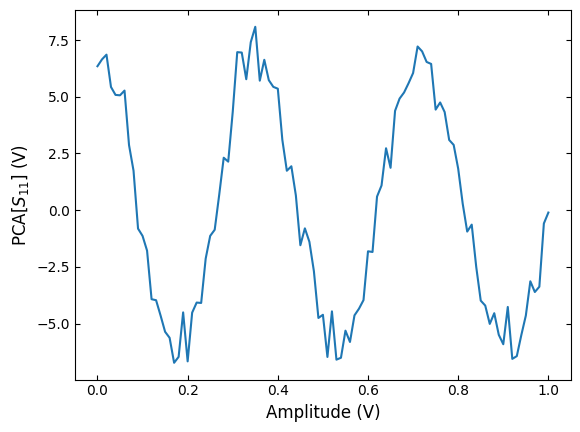

In [11]:
PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Amplitude (V)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (V)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

In [12]:
par_ini= {
    'amp': 7,
    'phi0':np.pi,
    'detun':1/0.38,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [13]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result = model.fit(data = PCA_amp[0], params = params, delay = x)
result

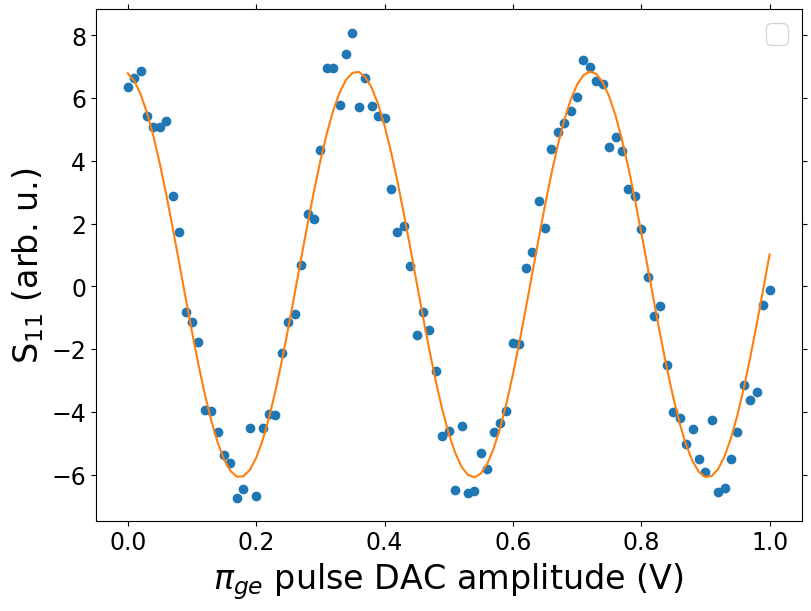

In [14]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
# plt.plot(x,result.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ge}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
# plt.savefig('ge_rabi.png', bbox_inches='tight')
plt.show()

In [15]:
np.pi/(2.74435624	*2*np.pi)*5

0.9109604516941283

ramsey

In [16]:
pl ="/2024-01-04/2024-01-04T134001_52bc221f-23_ge_T2r1d"
mi =  "/2024-01-04/2024-01-04T133926_3d661a7b-23_ge_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [17]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

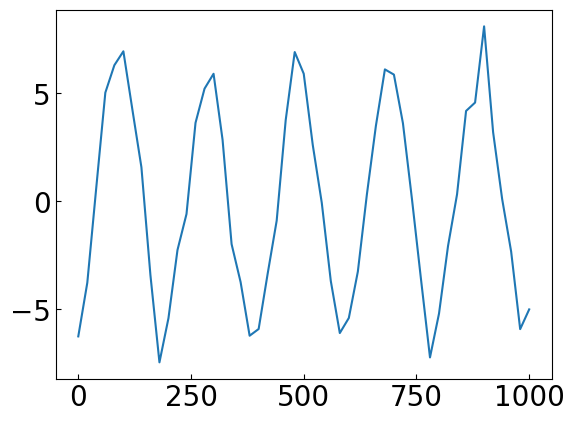

In [18]:
I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [19]:
par_ini_pl = {
    'amp': 7.5,
    'phi0':np.pi/2,
    'detun':1/200,
    'const':0.1
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [20]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

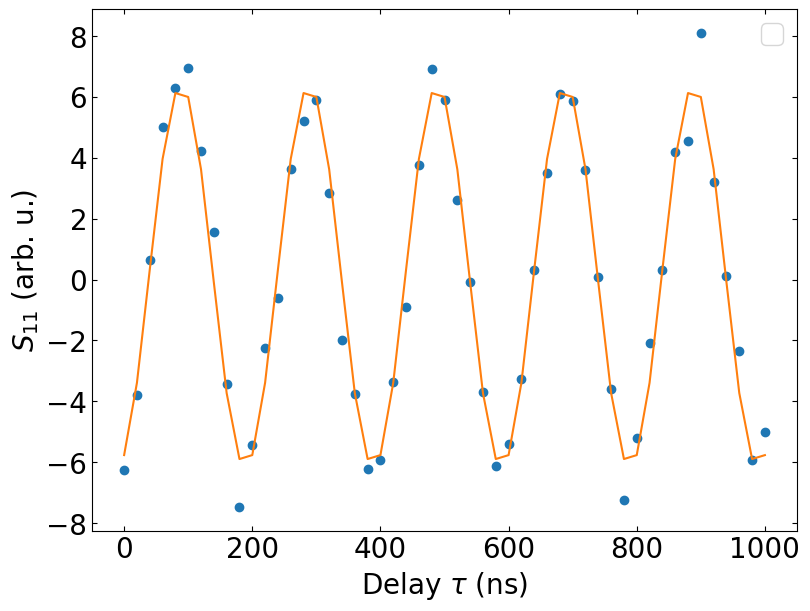

In [21]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)

# plt.title("Rabi(+5MHz)")

# plt.plot(x_pl,result_pl.init_fit)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

result_pl.plot_fit(ax = ax)
plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_ramsey.png', bbox_inches='tight')

plt.show()

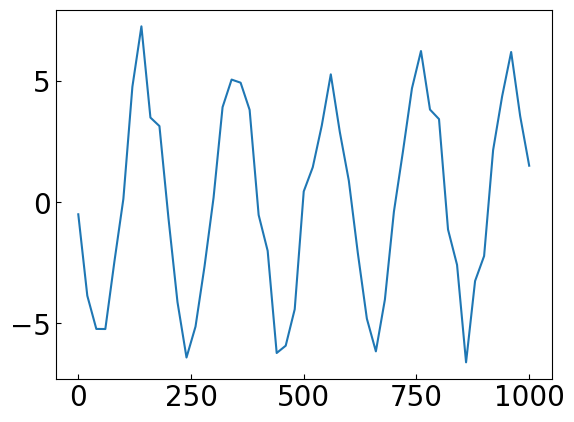

In [22]:
plt.plot(x_mi, y_mi)
plt.show()

In [23]:
par_ini_mi = {
    'amp': 7.5,
    'phi0':-np.pi/2,
    'detun':1/200,
    'const':0
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [24]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

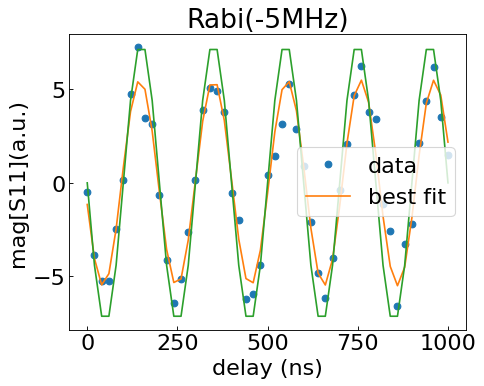

In [25]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_mi.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [26]:
detun = ((0.005-0.00490143)+ (0.00499991-0.005))/2 #GHz
detun

4.9239999999999874e-05

drag

In [27]:
drag = "/2024-01-04/2024-01-04T134739_639925c0-22_ge_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-01-04/2024-01-04T134833_837769a0-22_ge_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-01-04/2024-01-04T134927_a3a16dff-22_ge_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [28]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [29]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

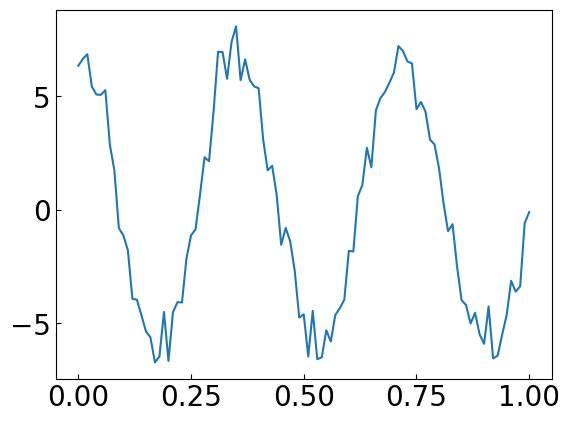

In [30]:
PCA_drag = PCA_transform1(I_amp, Q_amp, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_amp, Q_amp, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_amp, Q_amp, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

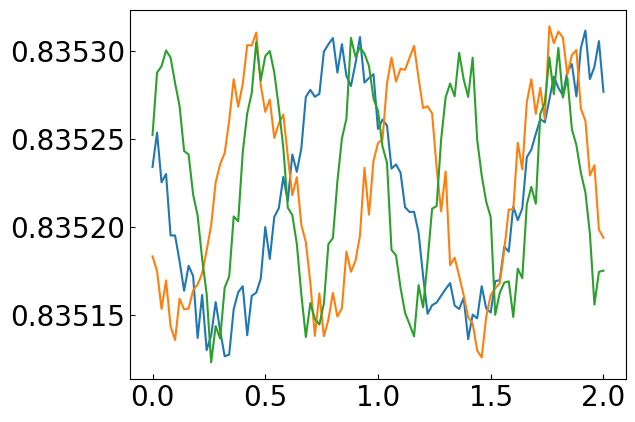

In [31]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [32]:
par_ini= {
    'amp': 0.00007,
    'phi0':np.pi,
    'detun':1/0.5,
    'const':0.83523,
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.pi
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [33]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [34]:
result0

In [35]:
res0 = (3*np.pi+1.86044553	)/(2*np.pi*0.94199272	)
res0

1.9067016807228838

In [36]:
result1

In [37]:
res1 = (5*np.pi+1.08291826)/(2*np.pi*1.49455791)
res1

1.788055033641001

In [38]:
result2

In [39]:
res2 = (9*np.pi-2.24655138)/(2*np.pi*2.30550459)
res2

1.7967651250536358

In [40]:
beta = (res0 + res1 + res2)/3
beta

1.8305072798058404

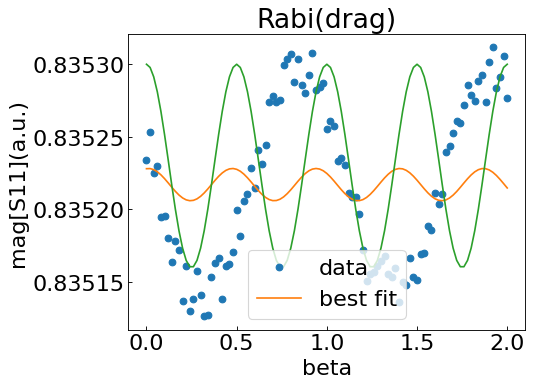

In [41]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

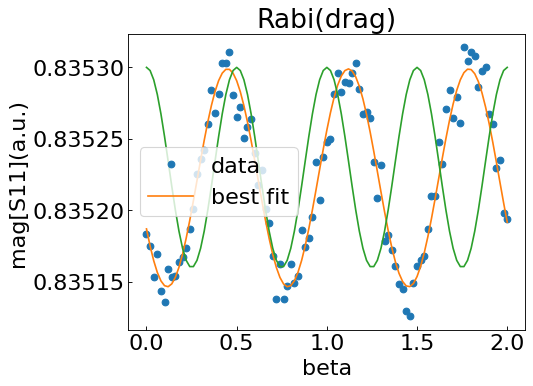

In [42]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

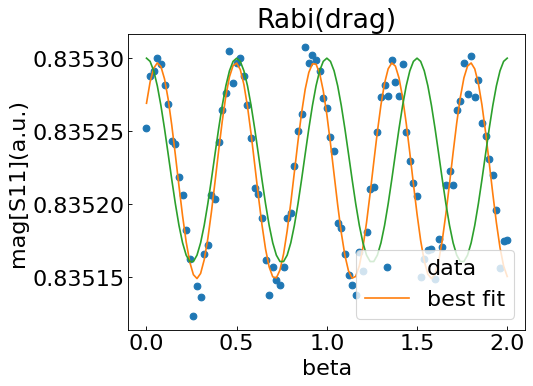

In [43]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


half drag

In [44]:
drag = "/2024-01-04/2024-01-04T140335_9d1c4048-22_ge_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-01-04/2024-01-04T140428_bd3009da-22_ge_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-01-04/2024-01-04T140523_dd66e190-22_ge_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [45]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [46]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

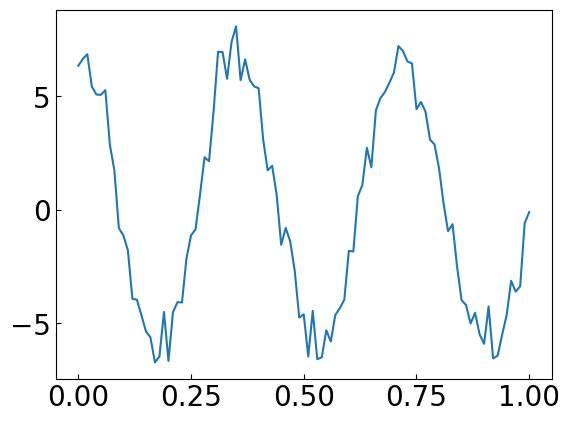

In [47]:
PCA_drag = PCA_transform1(I_amp, Q_amp, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_amp, Q_amp, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_amp, Q_amp, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

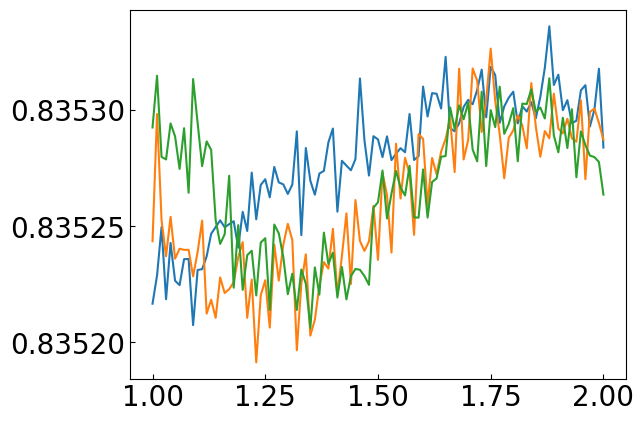

In [48]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [49]:
par_ini= {
    'amp': 0.00005,
    'phi0':0,
    'detun':1/1.5,
    'const':0.83525
}
par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}
par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}
par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [50]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [51]:
result0

In [52]:
res0 = (3*np.pi-6.12025175)/(2*np.pi*0.28159114)
res0

1.8677138812701175

In [53]:
result1

In [54]:
res1 = (3*np.pi+0.68975699)/(2*np.pi*0.88685508)
res1

1.8151536488810405

In [55]:
result2

In [56]:
res2 = (3*np.pi+3.30693429)/(2*np.pi*1.12696259)
res2

1.7980321234386207

In [57]:
beta = (res0 + res1 + res2)/3
beta

1.826966551196593

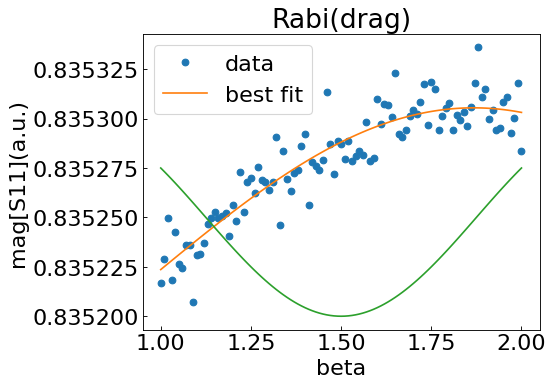

In [58]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

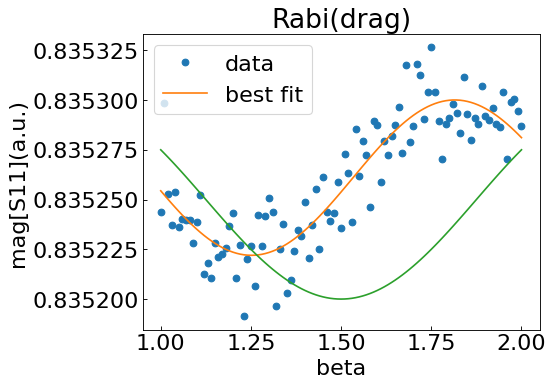

In [59]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

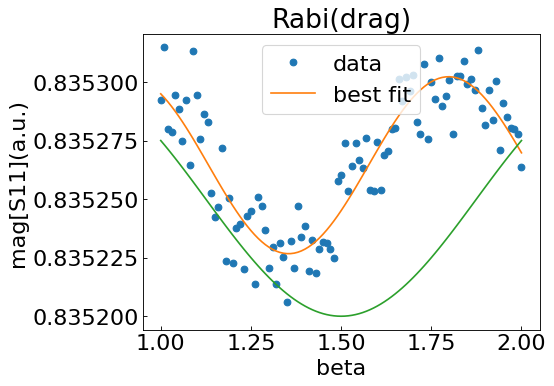

In [60]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


T1

In [84]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2024-01-04/2024-01-04T145054_39bc29f5-24_ge_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

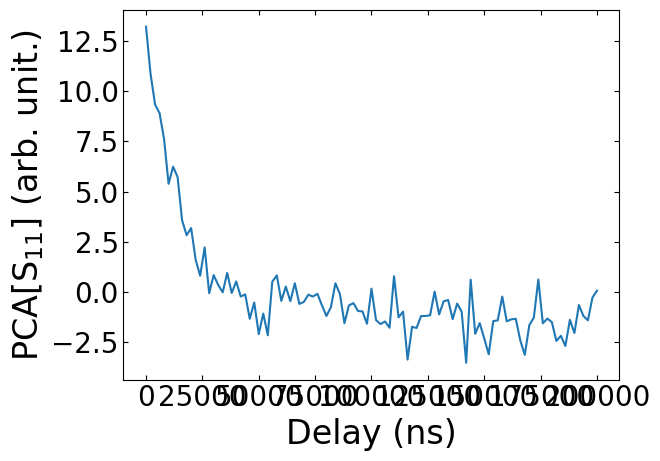

In [85]:
s11_t1 = dd_t1['s11']['values']#[0:247]
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values']#[0:247]

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
ang_t1 = np.angle(s11_t1)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Delay (ns)', size='large')
ax1.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')
plt.rcParams["font.size"] = 10
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.plot(x_t1, y_t1)
plt.show()

In [86]:
par_ini_t1 = {
    'gamma': 1/40000,
    'amp':15,
    'const':0
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [87]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1)
result_t1

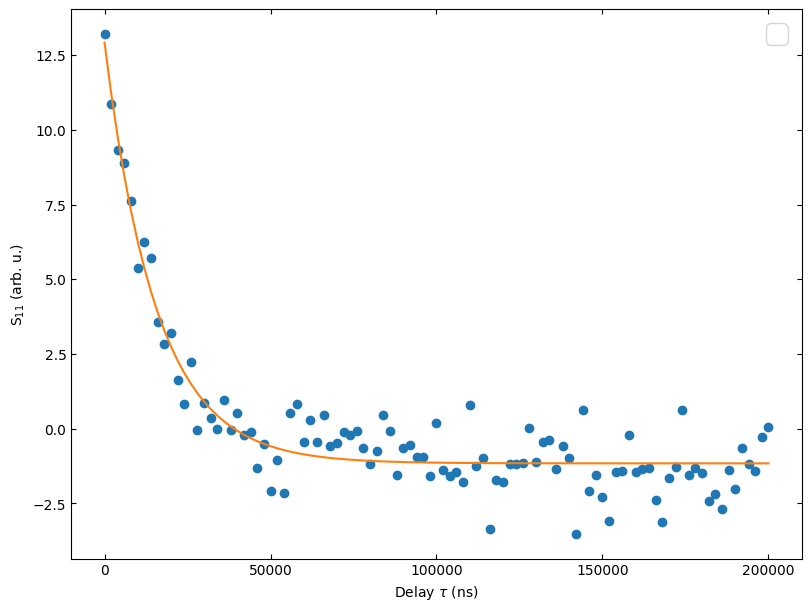

In [88]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

result_t1.plot_fit(ax = ax)
# plt.plot(x_t1,result_t1.init_fit, label='init fit')

# ax.set_ylim(-8, 15)
plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ (ns)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')
# plt.savefig('ge_T1.png', bbox_inches='tight')
plt.show()

In [89]:
T1 = (1/6.4012e-05)*1e-9	
T1

1.562207086171343e-05

T2_echo

In [67]:
t2e = "/2024-01-04/2024-01-04T145054_39bc29f5-24_ge_T1"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

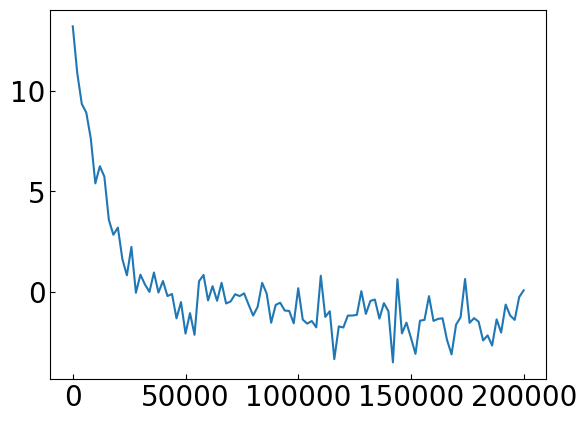

In [68]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [69]:
par_ini_t2e = {
    'gamma': 1/20000,
    'amp':10,
    'const':0
}

par_min_t2e = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t2e = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t2e = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [70]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e)
result_t2e

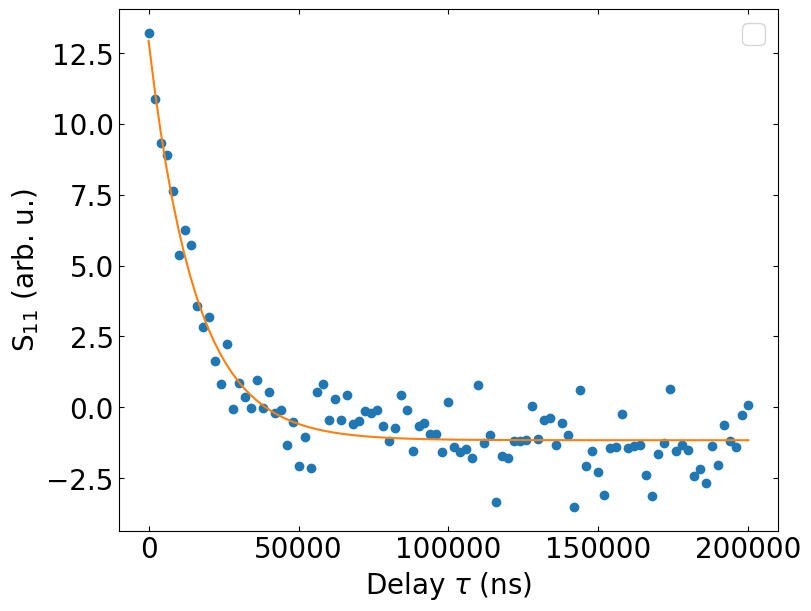

In [71]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
# plt.plot(delay_t2e,result_t2e.init_fit)

# ax.set_ylim(-10, 35)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ (ns)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
# plt.savefig('ge_T2e.png', bbox_inches='tight')
plt.show()

In [72]:
T2 = (1/2.0846e-04)*1e-9	
T2

4.797083373309029e-06

T2 star

In [73]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [74]:
t2 = "/2024-01-04/2024-01-04T141722_89fe1f5b-23_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

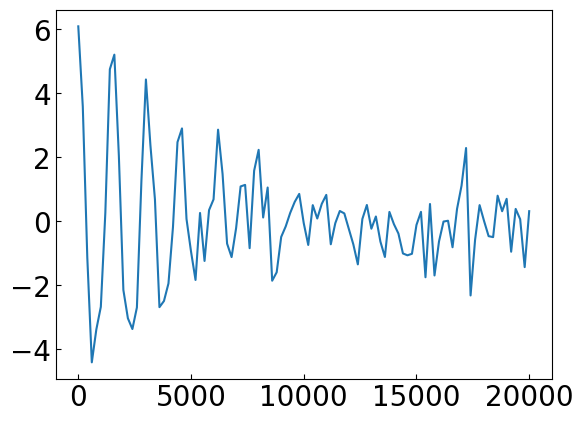

In [75]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [76]:
par_ini_t2 = {
    'amp':8,
    'gamma': 1/15000,
    'omega':2*np.pi/1500,
    'phi0':0,
    'const':0
}

par_min_t2 = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max_t2 = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary_t2 = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [77]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2[name],
    min = par_min_t2[name],
    max = par_max_t2[name],
    vary = par_vary_t2[name]
    )
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2)
result_t2

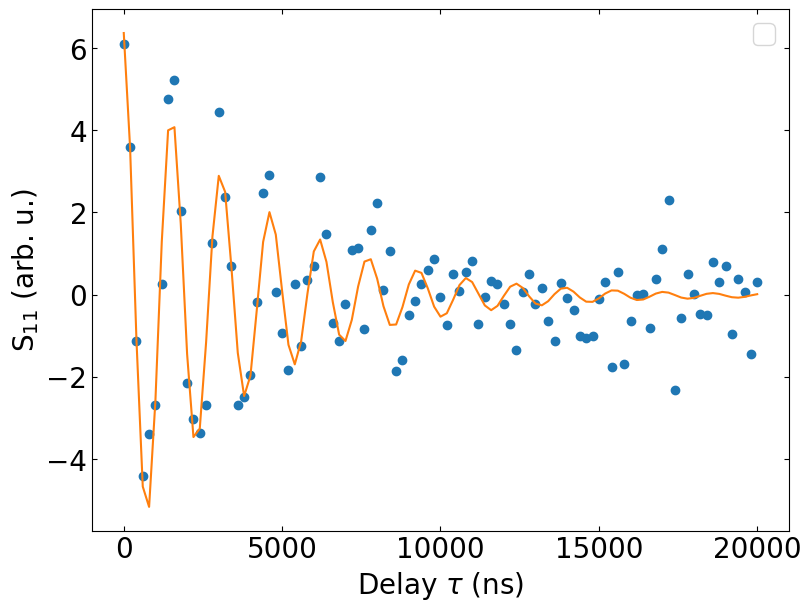

In [78]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
# plt.plot(delay_t2,result_t2.init_fit)
# ax.set_ylim(-10, 35)
plt.title("")
plt.legend("")
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel(r'Delay $\tau$ (ns)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
# plt.savefig('ge_T2star.png', bbox_inches='tight')
plt.show()

In [79]:
T2_star = (1/2.4991e-04)*1e-9	
T2_star

4.001440518586692e-06